# Plotting light curves of the simulations

(Lamb, Tanaka and Kobayashi 2018)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
import pickle
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad
from tqdm.notebook import tqdm

In [2]:
def ObsTime(t, mag):
    index = []
    for i in range(len(mag)-1):
        if mag[i] < 24.5:
            index.append(i)
    if not index:
        return 0
    else:
        dt = (t[max(index)] - t[min(index)])*grb.sec2day
        return dt

## 1. Top-Hat Jet

  0%|          | 0/1000 [00:00<?, ?it/s]

69 observable off-axis afterglow(s).
94 on-axis afterglow(s) for 906 off-axis afterglow(s) (ratio = 0.10).


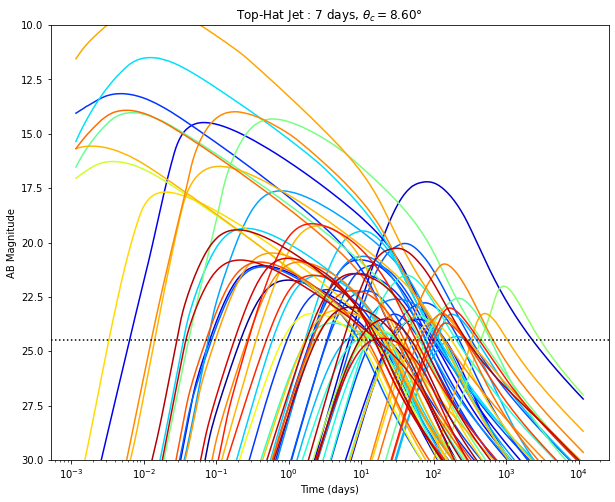

In [3]:
file_open = open('../data/simulations/all_dico_015.pkl', 'rb')
configs_open = pickle.load(file_open)

t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

plt.figure(figsize=(10.,8.))

n_off_obs = 0
n_off = 0
n_on = 0

for i in tqdm(range(1000)):
    Z = configs_open[i]
    Z['jetType'] = grb.jet.TopHat
    Z['thetaCore'] = 0.15
    
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    dt = ObsTime(t, mag)
    
    if dt > 7.:
        
        # Plot off-axis
        if Z['thetaCore'] < Z['thetaObs']:
            n_off_obs = n_off_obs+1
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'OFF-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_c$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaCore']), math.degrees(Z['thetaObs'])))
        
        # Plot on-axis
        #else:
            #plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'ON-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_c$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaCore']), math.degrees(Z['thetaObs'])))

    if Z['thetaCore'] < Z['thetaObs']:
        n_off = n_off+1
    else:
        n_on = n_on+1 
     
print ('%i observable off-axis afterglow(s).' %n_off_obs)
print ('%i on-axis afterglow(s) for %i off-axis afterglow(s) (ratio = %.2f).' %(n_on, n_off, n_on/n_off))

plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')

plt.title(r'Top-Hat Jet : 7 days, $\theta_c = 8.60°$')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.ylim(30,10)
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

file_open.close()

## 2. Gaussian Jet
#### 2.1 $\theta_c$ = 0.05 radians

  0%|          | 0/1000 [00:00<?, ?it/s]

37 observable afterglow(s).
88 on-axis afterglow(s) for 912 off-axis afterglow(s) (ratio = 0.10).


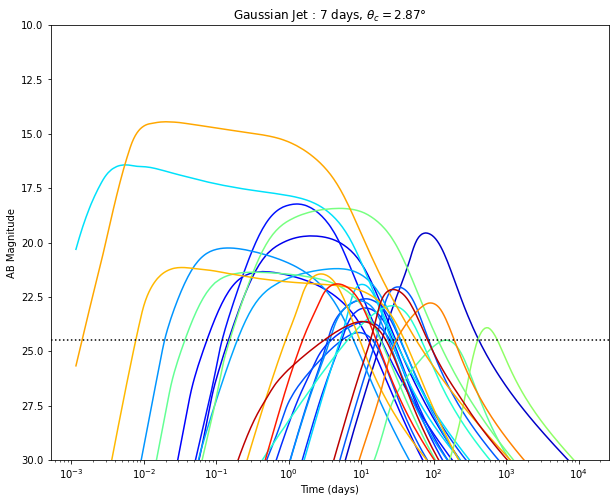

In [4]:
file_open = open('../data/simulations/all_dico_005.pkl', 'rb')
configs_open = pickle.load(file_open)

t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

plt.figure(figsize=(10.,8.))

n_off_obs = 0
n_off = 0
n_on = 0

for i in tqdm(range(1000)):
    Z = configs_open[i]
    
    Z['jetType'] = grb.jet.Gaussian
    
    if Z['thetaWing'] < Z['thetaObs']:
        n_off = n_off+1
    else:
        n_on = n_on+1
    E = np.random.normal(51,1)

    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    dt = ObsTime(t, mag)
    
    if dt > 7.:
        n_off_obs = n_off_obs+1
        if Z['thetaWing'] < Z['thetaObs']:
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'OFF-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))
        #else:
            #plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'ON-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))

print ('%i observable afterglow(s).' %n_off_obs)
print ('%i on-axis afterglow(s) for %i off-axis afterglow(s) (ratio = %.2f).' %(n_on, n_off, n_on/n_off))

# Enveloppe of on-axis (Kann 2008)
#plt.plot([0.001, 1.], [23, 29], color='k')
#plt.plot([0.001, 100], [8, 18], color='k')
plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')

plt.title(r'Gaussian Jet : 7 days, $\theta_c = 2.87°$')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.ylim(30,10)
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

file_open.close()

#### 2.2 $\theta_c$ = 0.15 radians

  0%|          | 0/1000 [00:00<?, ?it/s]

109 observable afterglow(s).
129 on-axis afterglow(s) for 871 off-axis afterglow(s) (ratio = 0.15).


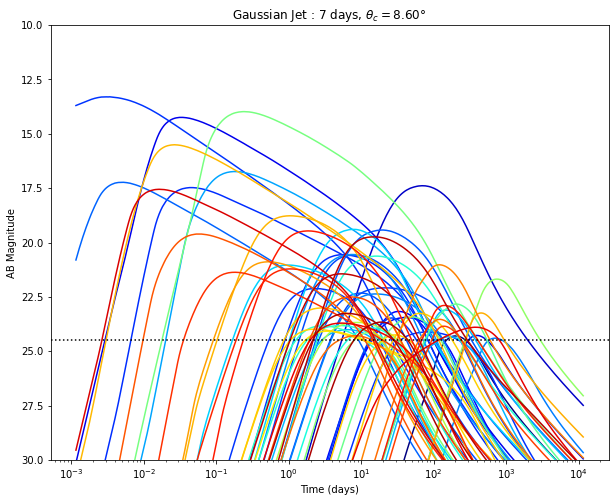

In [5]:
file_open = open('../data/simulations/all_dico_015.pkl', 'rb')
configs_open = pickle.load(file_open)

t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

plt.figure(figsize=(10.,8.))

n_off_obs = 0
n_off = 0
n_on = 0

for i in tqdm(range(1000)):
    Z = configs_open[i]
    
    Z['jetType'] = grb.jet.Gaussian
    Z['thetaCore'] = 0.15
    
    if Z['thetaWing'] < Z['thetaObs']:
        n_off = n_off+1
    else:
        n_on = n_on+1
    E = np.random.normal(51,1)

    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    dt = ObsTime(t, mag)
    
    if dt > 7.:
        n_off_obs = n_off_obs+1
        if Z['thetaWing'] < Z['thetaObs']:
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'OFF-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))
        #else:
            #plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'ON-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))

print ('%i observable afterglow(s).' %n_off_obs)
print ('%i on-axis afterglow(s) for %i off-axis afterglow(s) (ratio = %.2f).' %(n_on, n_off, n_on/n_off))

#plt.plot([0.001, 1.], [23, 29], color='k')
#plt.plot([0.001, 100], [8, 18], color='k')
plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')

plt.title(r'Gaussian Jet : 7 days, $\theta_c = 8.60°$')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.ylim(30,10)
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

file_open.close()

## 3. Power-Law Jet
#### 3.1 $\theta_c$ = 0.05 radians

  0%|          | 0/1000 [00:00<?, ?it/s]

29 observable off-axis afterglow(s).
88 on-axis afterglow(s) for 912 off-axis afterglow(s) (ratio = 0.10).


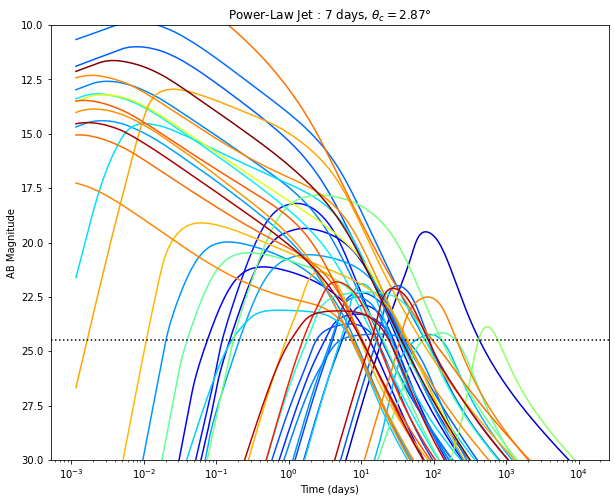

In [6]:
file_open = open('../data/simulations/all_dico_005.pkl', 'rb')
configs_open = pickle.load(file_open)

t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

plt.figure(figsize=(10.,8.))

n_off_obs = 0
n_off = 0
n_on = 0
    
for i in tqdm(range(1000)):
    Z = configs_open[i]
    
    Z['jetType'] = grb.jet.PowerLaw
    
    if Z['thetaWing'] < Z['thetaObs']:
        n_off = n_off+1
    else:
        n_on = n_on+1
    
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    dt = ObsTime(t, mag)
    
    if dt > 7.:
        if Z['thetaWing'] < Z['thetaObs']:
            n_off_obs = n_off_obs+1
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'OFF-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))
        else:
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'ON-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))

print ('%i observable off-axis afterglow(s).' %n_off_obs)
print ('%i on-axis afterglow(s) for %i off-axis afterglow(s) (ratio = %.2f).' %(n_on, n_off, n_on/n_off))

#plt.plot([0.001, 1.], [23, 29], color='k')
#plt.plot([0.001, 100], [8, 18], color='k')
plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')

plt.title(r'Power-Law Jet : 7 days, $\theta_c = 2.87°$')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.ylim(30,10)
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

file_open.close()

#### 3.2 $\theta_c$ = 0.15 radians 

  0%|          | 0/1000 [00:00<?, ?it/s]

66 observable off-axis afterglow(s).
129 on-axis afterglow(s) for 871 off-axis afterglow(s) (ratio = 0.15).


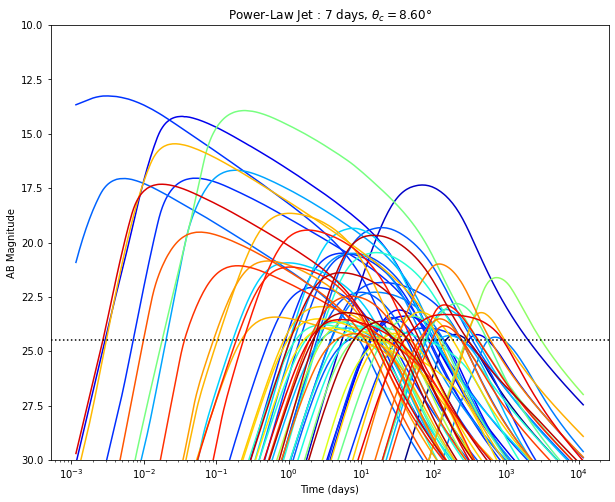

In [7]:
file_open = open('../data/simulations/all_dico_015.pkl', 'rb')
configs_open = pickle.load(file_open)

t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

plt.figure(figsize=(10.,8.))

n_off_obs = 0
n_off = 0
n_on = 0
    
for i in tqdm(range(1000)):
    Z = configs_open[i]
    
    Z['jetType'] = grb.jet.PowerLaw
    Z['thetaCore'] = 0.15
    
    if Z['thetaWing'] < Z['thetaObs']:
        n_off = n_off+1
    else:
        n_on = n_on+1
    
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
    dt = ObsTime(t, mag)
    
    if dt > 7.:
        if Z['thetaWing'] < Z['thetaObs']:
            n_off_obs = n_off_obs+1
            plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'OFF-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))
        #else:
            #plt.plot(t*grb.sec2day, mag, color = cm.jet(i/1000), label = r'ON-AXIS : log$_{10}(E_0)$ = %.2f, n$_0$ = %.3f cm$^{-3}$, z = % .2f, $\theta_w$ = %.2f°, $\theta_{obs}$ = %.2f°' %(np.log10(Z['E0']), Z['n0'], Z['z'], math.degrees(Z['thetaWing']), math.degrees(Z['thetaObs'])))

print ('%i observable off-axis afterglow(s).' %n_off_obs)
print ('%i on-axis afterglow(s) for %i off-axis afterglow(s) (ratio = %.2f).' %(n_on, n_off, n_on/n_off))

#plt.plot([0.001, 1.], [23, 29], color='k')
#plt.plot([0.001, 100], [8, 18], color='k')
plt.axhline(y=24.5, color='black', linestyle=':', label='LSST limiting magnitude')

plt.title(r'Power-Law Jet : 7 days, $\theta_c = 8.60°$')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.ylim(30,10)
#plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

file_open.close()